In [ ]:
import kagglehub

path = kagglehub.dataset_download("arnavsharma45/mnist-dataset")

print("Path to dataset files:", path)

100%|██████████| 9.14M/9.14M [00:00<00:00, 40.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arnavsharma45/mnist-dataset/versions/1


Loading MNIST dataset...
Number of samples: 70000
Number of classes: 10
Image dimensions: 28 x 28 pixels (784 features)


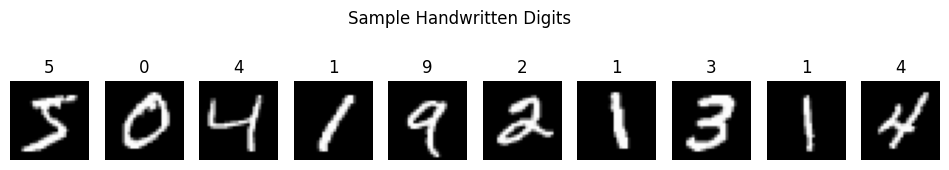

Data normalized. Min value: 0.0, Max value: 1.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml

print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Image dimensions: 28 x 28 pixels ({X.shape[1]} features)")

fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
  ax.imshow(X[i].reshape(28, 28), cmap='gray')
  ax.set_title(str(y[i]))
  ax.axis('off')
plt.suptitle('Sample Handwritten Digits', y=1.05)
plt.show()

X_normalized = X / 255.0
print(f"Data normalized. Min value: {X_normalized.min()}, Max value: {X_normalized.max()}")


Components for 90% variance: 86
Components for 95% variance: 151
Components for 99% variance: 326


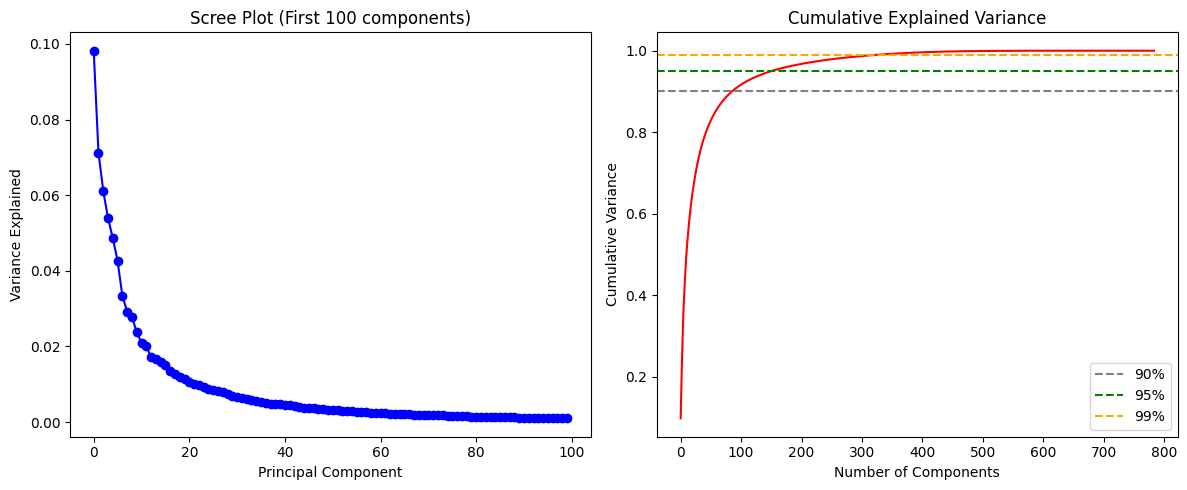

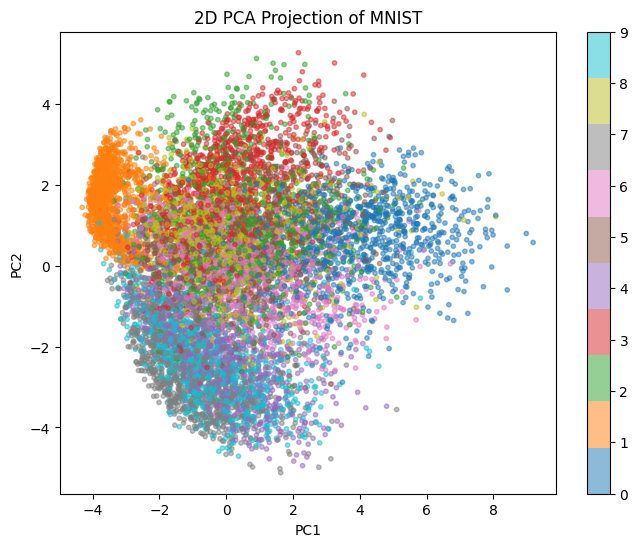

In [ ]:
from sklearn.decomposition import PCA

np.random.seed(42)
subset_indices = np.random.choice(X_normalized.shape[0], 10000, replace=False)
X_subset = X_normalized[subset_indices]
y_subset = y[subset_indices]

pca = PCA()
pca.fit(X_subset)

cum_var = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
n_99 = np.argmax(cum_var >= 0.99) + 1

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(pca.explained_variance_ratio_[:100], marker='o', color='b')
plt.title('Scree Plot (First 100 components)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')

plt.subplot(1, 2, 2)
plt.plot(cum_var, color='r')
plt.axhline(0.90, color='grey', linestyle='--', label='90%')
plt.axhline(0.95, color='green', linestyle='--', label='95%')
plt.axhline(0.99, color='orange', linestyle='--', label='99%')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.tight_layout()
plt.show()

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_subset)

pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X_subset)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_subset, cmap='tab10', alpha=0.5, s=10
)
plt.colorbar(scatter, ticks=range(10))
plt.title('2D PCA Projection of MNIST')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarnin

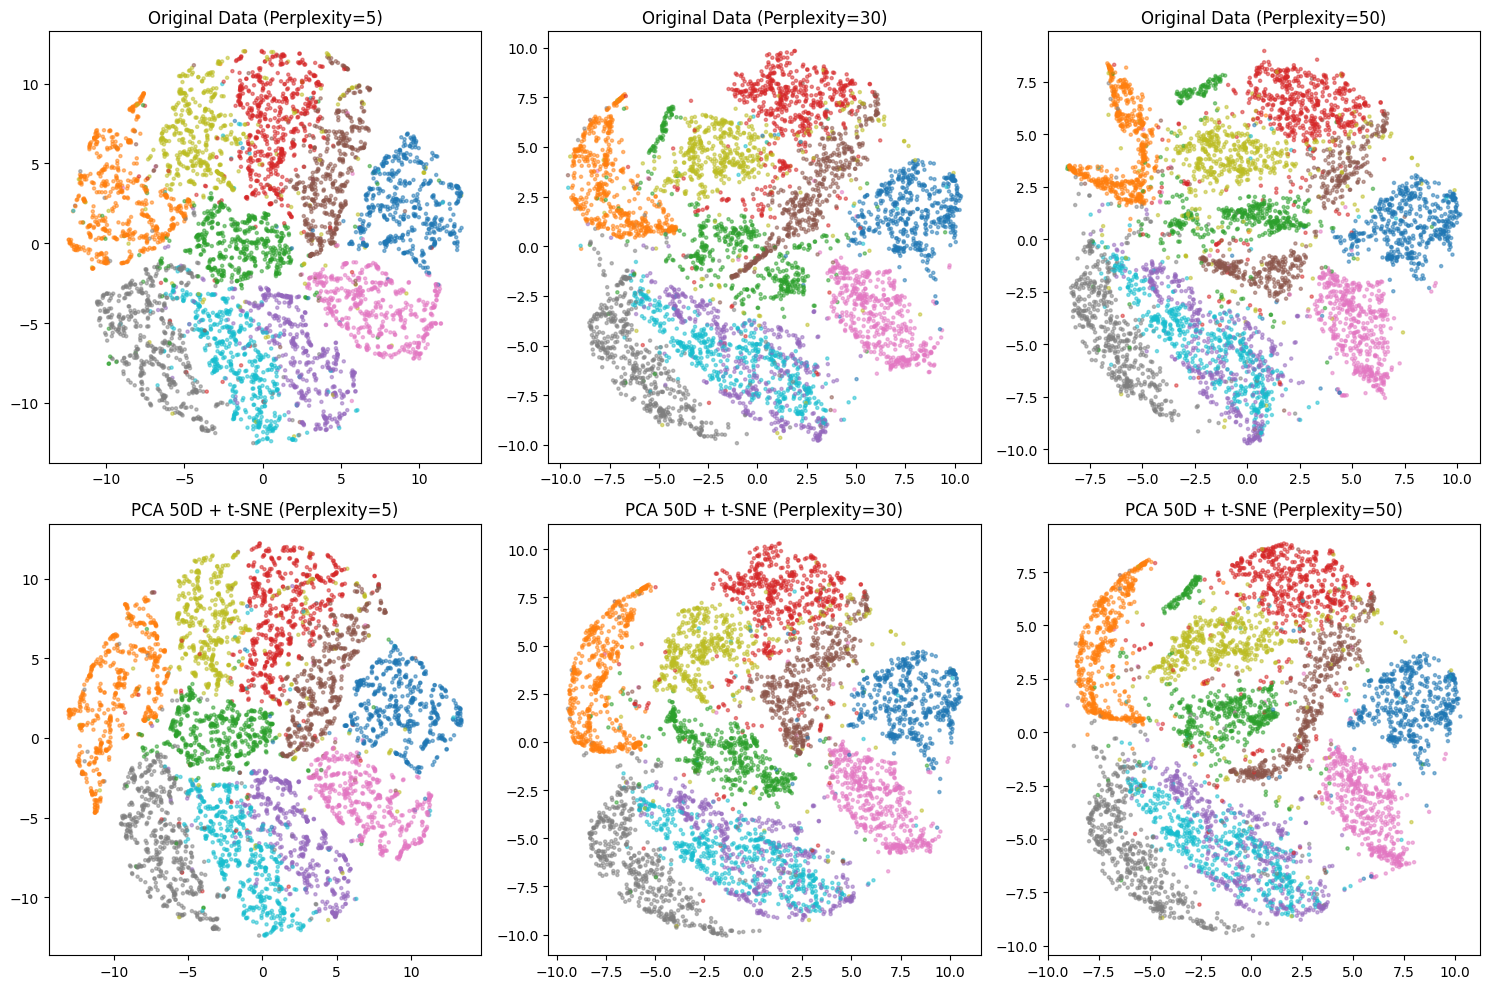

In [ ]:
from sklearn.manifold import TSNE

perplexities = [5, 30, 50]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, perp in enumerate(perplexities):
  tsne_orig = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=300)
  X_tsne_orig = tsne_orig.fit_transform(X_subset)

  axes[0, i].scatter(
      X_tsne_orig[:, 0],
      X_tsne_orig[:, 1],
      c=y_subset,
      cmap='tab10',
      alpha=0.5,
      s=5,
  )
  axes[0, i].set_title(f'Original Data (Perplexity={perp})')

  tsne_pca = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=300)
  X_tsne_pca = tsne_pca.fit_transform(X_pca_50)

  axes[1, i].scatter(
      X_tsne_pca[:, 0],
      X_tsne_pca[:, 1],
      c=y_subset,
      cmap='tab10',
      alpha=0.5,
      s=5,
  )
  axes[1, i].set_title(f'PCA 50D + t-SNE (Perplexity={perp})')

plt.tight_layout()
plt.show()


In [ ]:
import time
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

X_train_50, X_test_50, _, _ = train_test_split(
    X_pca_50, y_subset, test_size=0.2, random_state=42
)

configs = {
    'Original (784D)': (X_train, X_test),
    'PCA-Reduced (50D)': (X_train_50, X_test_50),
}

for name, (X_tr, X_te) in configs.items():
  print(f'\n--- Evaluating Classifier on {name} ---')
  knn = KNeighborsClassifier(n_neighbors=3)

  start_train = time.time()
  knn.fit(X_tr, y_train)
  train_time = time.time() - start_train

  start_pred = time.time()
  y_pred = knn.predict(X_te)
  pred_time = time.time() - start_pred

  acc = accuracy_score(y_test, y_pred)
  print(f'Training Time: {train_time:.4f} seconds')
  print(f'Prediction Time: {pred_time:.4f} seconds')
  print(f'Accuracy: {acc * 100:.2f}%')



--- Evaluating Classifier on Original (784D) ---
Training Time: 0.0203 seconds
Prediction Time: 0.5618 seconds
Accuracy: 92.80%

--- Evaluating Classifier on PCA-Reduced (50D) ---
Training Time: 0.0018 seconds
Prediction Time: 0.0747 seconds
Accuracy: 93.90%
